In [1]:
# X_{n+1} = e^{−1} X_n+1−e^{−2} ξ_n
import numpy as np
import pandas as pd


def simulate_ou(n_steps, random_state, x0=0.0):
    rng = np.random.default_rng(random_state)
    x = np.empty(n_steps, dtype=float)
    x[0] = float(x0)
    a = np.exp(-1.0)
    b = np.sqrt(1.0 - np.exp(-2.0))
    for t in range(n_steps - 1):
        x[t + 1] = a * x[t] + b * rng.standard_normal()
    return pd.DataFrame({"x": x})


In [2]:
# General gaussian invariant distribution: ξ_n ∼ N(0,1) for OU, not actually used for this figure
# Actual density used is below
def stationary_density(x, theta=1.0, mu=0.0, sigma=1.0):
    var = sigma**2 / (2 * theta)
    return np.exp(-((x - mu) ** 2) / (2 * var)) / np.sqrt(2 * np.pi * var)


In [19]:
# OU specific normalisation constant

from kooplearn._linalg import weighted_norm


def ou_normalisation(functions, x, density):
    #    abs2 = np.abs(functions) ** 2
    #    norms = np.sqrt(np.trapezoid(abs2 * density[:, None], x[:, 0], axis=0))
    W = np.diag(density.reshape(-1))
    norms = weighted_norm(functions, W)
    norms = np.maximum(norms, 1e-12)
    functions = functions / norms
    return functions


In [20]:
# Some reused variables
from kooplearn.preprocessing import FeatureFlattener

n_train_samples = 1000
subsample = 50

x = np.linspace(-4, 4, 1025)[:, None]

flattener = FeatureFlattener()
x_flat = flattener.fit_transform(x)

# This is the exact density used in the paper for OU
density = np.exp(-0.5 * x_flat**2) / np.sqrt(2 * np.pi)

100%|██████████| 10/10 [00:03<00:00,  3.04it/s]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


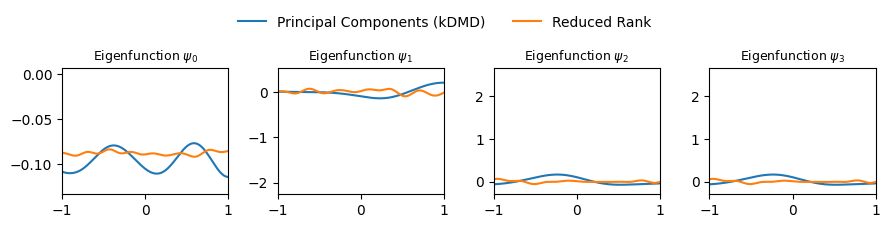

In [21]:
# First, Fig. 2 but with OU

from collections import defaultdict

import matplotlib.pyplot as plt
from tqdm import tqdm

from kooplearn.kernel import KernelRidge


def fit_and_estimate(reduced_rank, x, density, random_state):
    # Substitute Langevin with OU
    data = simulate_ou(
        n_steps=int(7e5),
        random_state=random_state,
        x0=0.0,
    )

    # Sample new trajectories
    data = data.iloc[
        ::subsample  # don't need all data
    ]
    data = data[:n_train_samples]

    # Model definition, same as fig 2 for now
    model = KernelRidge(
        n_components=5,
        reduced_rank=reduced_rank,
        gamma=12.5,
        kernel="rbf",
        alpha=1e-6,
        random_state=random_state,
    )

    # Fit and estimate eigenfunctions
    model.fit(data)  # fit transfer op model
    values, functions = model.eig(
        eval_right_on=x
    )  # (right) eigenvalue estimation, evaluate on array x
    sort_perm = np.flip(np.argsort(np.abs(values)))  # Order decreasingly
    values, functions = values[sort_perm], functions[:, sort_perm]
    functions = ou_normalisation(functions, x, density)
    return functions


# Run functions for both RRR (reduced rank) and kDMD (full rank) estimators
dt = 1e-4
n_repetitions = 10
results = defaultdict(list)
for method, reduced_rank in zip(["Principal Components (kDMD)", "Reduced Rank"], [False, True]):
    for i in tqdm(range(n_repetitions)):
        results[method].append(fit_and_estimate(reduced_rank, x, density, i))

# Print results
fig, axs = plt.subplots(ncols=4, figsize=(9, 2))
for fun_id, ax in enumerate(axs):
    for method, functions in results.items():
        color = "tab:blue" if "Principal" in method else "tab:orange"
        ax.plot(x, functions[0][:, fun_id], color=color, label=method)
    ax.set_title(rf"Eigenfunction $\psi_{fun_id}$", fontsize=9)
    ax.set_xlim(-1, 1)
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncols=2,
    frameon=False,
    bbox_to_anchor=(0.0, 1.05, 1.0, 0.102),
)
plt.tight_layout()
plt.show()


## Figure 1 reproduction
### Kernel family
$$k_{\Pi,\nu}(x,x')=\sum_{i\in\mathbb N}\mu_{\Pi(i)}^{2\nu} f_i(x)f_i(x')$$

ugly-RRR:  50%|█████     | 2/4 [01:01<01:01, 30.75s/it]/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/kernel/_regressors.py:496: UserWarning: Warning: 3 out of the 4 squared singular values are smaller than the regularization strength 1.00e-06. Consider reducing the regularization strength to avoid overfitting.
  warn(
ugly-RRR:  75%|███████▌  | 3/4 [01:32<00:30, 30.64s/it]/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/kernel/_regressors.py:496: UserWarning: Warning: 1 out of the 4 squared singular values are smaller than the regularization strength 1.00e-06. Consider reducing the regularization strength to avoid overfitting.
  warn(
ugly-RRR: 100%|██████████| 4/4 [02:02<00:00, 30.66s/it]


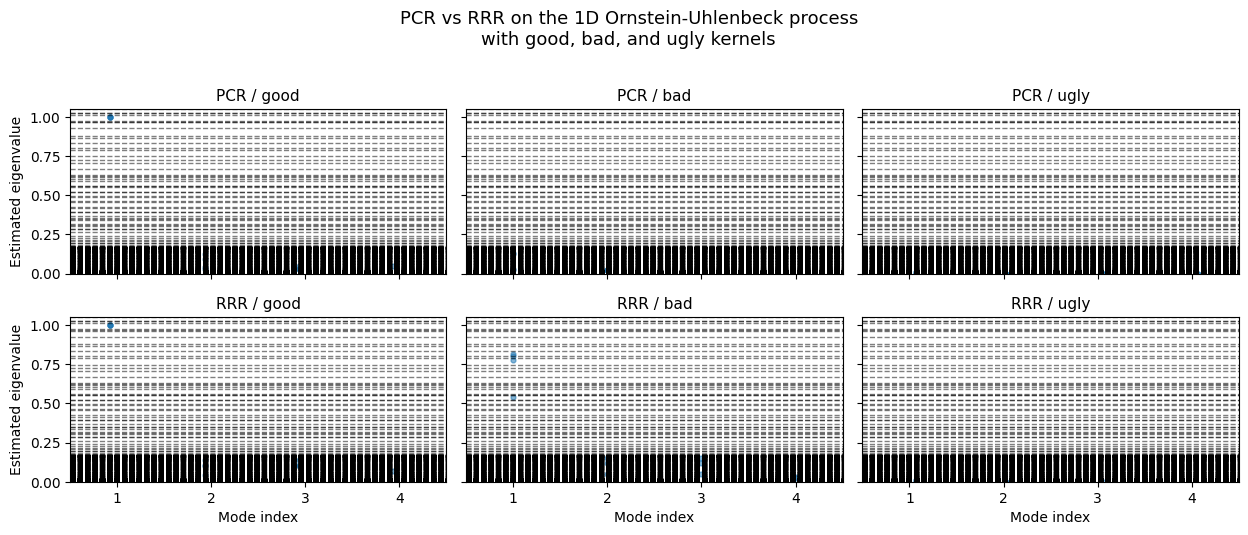

In [22]:
from collections import defaultdict
from math import factorial

import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermval
from tqdm import tqdm

from kooplearn._utils import stable_topk
from kooplearn.kernel import KernelRidge

n_trials = 4  # Paper explicity runs 50 trials
n_show = 4
M = 10


# helpers to make hermite kernel
# ==============================
def hermite_prob(n, x):
    c = np.zeros(n + 1)
    c[n] = 1.0
    return hermval(x, c)


def hermite_features(x, M):
    x = np.asarray(x).reshape(-1)
    Phi = np.zeros((x.shape[0], M))
    for j in range(M):
        Phi[:, j] = hermite_prob(j, x) / np.sqrt(factorial(j))
    return Phi


def kernel_permutation(kind, r, M):
    pi = np.arange(M)

    if kind == "good":
        return pi

    if kind == "bad":
        if 2 * r > M:
            raise ValueError(f"Need M >= 2*r for bad kernel, got M={M}, r={r}")
        pi2 = pi.copy()
        a = np.arange(r)
        b = np.arange(r, 2 * r)
        pi2[a] = b[::-1]
        pi2[b] = a[::-1]
        return pi2

    if kind == "ugly":
        return pi[::-1]

    raise ValueError(kind)


def make_weights(kind, r, M):
    mu = np.exp(-np.arange(M))
    nu = 1.0 if kind == "good" else (1.0 / (r**2) if kind == "bad" else r**2)
    pi = kernel_permutation(kind, r, M)
    return mu[pi] ** (2.0 * nu)


def hermite_kernel(kind, r, M):
    w = make_weights(kind, r, M)

    def kernel(x, y):
        x = np.asarray(x).ravel()
        y = np.asarray(y).ravel()
        sx = 0.0
        for m in range(M):
            fx = hermite_prob(m, x[0]) / np.sqrt(factorial(m))
            fy = hermite_prob(m, y[0]) / np.sqrt(factorial(m))
            sx += w[m] * fx * fy
        return float(sx)

    return kernel


# redefine fit_and_estimate with new kernel callable
# ==================================================
def fit_and_estimate(reduced_rank, x, density, random_state, kind, r):
    data = simulate_ou(n_steps=20000, random_state=random_state)
    data = data.iloc[
        ::subsample  # don't need all data
    ]
    data = data[:n_train_samples]

    model = KernelRidge(
        n_components=n_show,
        reduced_rank=reduced_rank,
        kernel=hermite_kernel(kind, r, M),
        alpha=1e-6,
        random_state=random_state,
    )

    model.fit(data)
    values, functions = model.eig(eval_right_on=x)
    sort_perm = np.flip(np.argsort(np.abs(values)))
    values, functions = values[sort_perm], functions[:, sort_perm]
    functions = ou_normalisation(functions, x, density)
    return values, functions


# Now find eigenfunctions of OU system with different kernels and plot
# ====================================================================
kernels = ["good", "bad", "ugly"]
methods = [("PCR", False), ("RRR", True)]
results = defaultdict(list)

for kind in kernels:
    for method, reduced_rank in methods:
        for trial in tqdm(range(n_trials), desc=f"{kind}-{method}"):
            values, functions = fit_and_estimate(
                reduced_rank=reduced_rank,
                x=x,
                density=density,
                random_state=trial,
                kind=kind,
                r=n_show,
            )
            # only top eigenfunctions
            vals, idx = stable_topk(values, k_max=n_show)
            top_eigs = functions[:, idx]
            tmp = np.full(n_show, np.nan)
            tmp[: min(n_show, len(vals))] = np.abs(vals[:n_show])
            results[(kind, method)].append(tmp)


# Plot side by side
fig, axs = plt.subplots(2, 3, figsize=(12.5, 5.2), sharex=True, sharey=True)

for i, (method, _) in enumerate(methods):
    for j, kind in enumerate(kernels):
        ax = axs[i, j]
        vals = np.array(results[(kind, method)])

        n_plot = min(n_show, vals.shape[1])

        for m in range(n_plot):
            y = vals[:, m]
            xj = np.full_like(y, m + 1, dtype=float) + 0.07 * (j - 1)
            ax.scatter(xj, y, s=12, alpha=0.55, color="tab:blue")

        top_eigs = np.asarray(top_eigs).ravel()

        for ev in top_eigs:
            ax.axhline(float(ev), color="black", lw=1, ls="--", alpha=0.5)
        ax.set_title(f"{method} / {kind}", fontsize=11)
        ax.set_xticks(range(1, n_show + 1))
        ax.set_xlim(0.5, n_show + 0.5)
        ax.set_ylim(0.0, 1.05)

axs[0, 0].set_ylabel("Estimated eigenvalue")
axs[1, 0].set_ylabel("Estimated eigenvalue")
for ax in axs[1, :]:
    ax.set_xlabel("Mode index")

fig.suptitle(
    "PCR vs RRR on the 1D Ornstein-Uhlenbeck process\nwith good, bad, and ugly kernels",
    y=1.02,
    fontsize=13,
)
plt.tight_layout()
plt.show()
